<a href="https://colab.research.google.com/github/chrisldz/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression, lasso_path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    r2_score, mean_squared_error, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_curve, auc, ConfusionMatrixDisplay, accuracy_score
)

import wbgapi as wb

np.random.seed(42)

print("Setup complete ✓")


Setup complete ✓


In [ ]:
INDICATORS = {
    # Growth outcome
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD': 'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG': 'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR': 'real_interest_rate',
    'PA.NUS.FCRF': 'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR': 'secondary_enrollment_gross',
    'SE.TER.ENRR': 'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS': 'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS': 'internet_users_pct',
    'IT.CEL.SETS.P2': 'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS': 'electricity_access_pct',
    'IS.ROD.PAVE.ZS': 'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SH.DYN.MORT': 'infant_mortality_per1000',
    'SP.POP.GROW': 'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5': 'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources / Energy
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS': 'renewable_energy_pct',
    'EN.ATM.CO2E.PC': 'co2_emissions_per_capita',
    'AG.LND.AGRI.ZS': 'agricultural_land_pct'
}

OUTCOME_VAR = 'gdp_growth_pc'
YEARS = list(range(2013, 2020))

raw_data = wb.data.DataFrame(
    list(INDICATORS.keys()),
    economy='all',
    time=YEARS,
    labels=False
)

print("Raw World Bank data downloaded ✓")
print("Raw shape:", raw_data.shape)


Raw World Bank data downloaded ✓
Raw shape: (8246, 7)


In [ ]:
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

# Keep countries with at least 60% observed indicators
country_data = country_data.dropna(thresh=int(0.60 * country_data.shape[1]))

# Keep indicators observed for at least 60% of countries
country_data = country_data.dropna(axis=1, thresh=int(0.60 * len(country_data)))

# Median impute remaining gaps
country_data = country_data.fillna(country_data.median(numeric_only=True))

# Keep only rows with the outcome present
country_data = country_data.dropna(subset=[OUTCOME_VAR]).copy()

# Construct binary crisis outcome
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)

feature_cols = [c for c in country_data.columns if c not in [OUTCOME_VAR, 'crisis']]

X = country_data[feature_cols].copy()
y_reg = country_data[OUTCOME_VAR].copy()
y_cls = country_data['crisis'].copy()

# 70/30 split
X_train_df, X_test_df, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls,
    test_size=0.30,
    random_state=42,
    stratify=y_cls
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_df)
X_test_scaled = scaler.transform(X_test_df)

X_train_scaled_df = pd.DataFrame(X_train_scaled, index=X_train_df.index, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, index=X_test_df.index, columns=feature_cols)

n_total = len(country_data)
n_train = len(X_train_df)
n_test = len(X_test_df)
p = len(feature_cols)
base_rate_total = y_cls.mean()
base_rate_test = y_cls_test.mean()

print(f"Final dataset: {n_total} countries")
print(f"Predictors retained: {p}")
print(f"Training countries: {n_train}")
print(f"Test countries: {n_test}")
print(f"Crisis countries (full sample): {int(y_cls.sum())}")
print(f"Non-crisis countries (full sample): {int((1-y_cls).sum())}")
print(f"Crisis base rate (full sample): {base_rate_total:.3f}")
print(f"Crisis base rate (test set): {base_rate_test:.3f}")


Final dataset: 243 countries
Predictors retained: 26
Training countries: 170
Test countries: 73
Crisis countries (full sample): 40
Non-crisis countries (full sample): 203
Crisis base rate (full sample): 0.165
Crisis base rate (test set): 0.164


# Phase 1

In [ ]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_reg_train)

y_train_pred_ols = ols_model.predict(X_train_scaled)
y_test_pred_ols = ols_model.predict(X_test_scaled)

ols_train_r2 = r2_score(y_reg_train, y_train_pred_ols)
ols_test_r2 = r2_score(y_reg_test, y_test_pred_ols)
ols_gap = ols_train_r2 - ols_test_r2
pn_ratio = p / n_train

print("=" * 50)
print("STEP 1.1 — OLS OVERFITTING")
print("=" * 50)
print(f"Training R²: {ols_train_r2:.4f}")
print(f"Test R²:     {ols_test_r2:.4f}")
print(f"Train - Test R² gap: {ols_gap:.4f}")
print(f"Predictor-to-observation ratio (p/n): {p}/{n_train} = {pn_ratio:.4f}")


STEP 1.1 — OLS OVERFITTING
Training R²: 0.5036
Test R²:     0.2373
Train - Test R² gap: 0.2663
Predictor-to-observation ratio (p/n): 26/170 = 0.1529


The training R² and test R² should be compared directly to judge whether OLS is overfitting. If the training R² is much higher than the test R², that means the model is fitting the training sample too closely and does not generalize well. In this setting, a relatively high predictor-to-observation ratio makes OLS unstable because the model has many coefficients to estimate but not that many countries in the training set. That keeps in-sample bias low, but it increases variance and uses up degrees of freedom, so the out-of-sample performance gets worse.

In [ ]:
lambda_grid = np.logspace(-2, 3, 100)

ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_reg_train)

lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_reg_train)

ridge_train_pred = ridge_cv.predict(X_train_scaled)
ridge_test_pred = ridge_cv.predict(X_test_scaled)

lasso_train_pred = lasso_cv.predict(X_train_scaled)
lasso_test_pred = lasso_cv.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_reg_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_reg_test, ridge_test_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_reg_test, ridge_test_pred))

lasso_train_r2 = r2_score(y_reg_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_reg_test, lasso_test_pred)
lasso_test_rmse = np.sqrt(mean_squared_error(y_reg_test, lasso_test_pred))

ridge_nonzero = int(np.sum(ridge_cv.coef_ != 0))
lasso_nonzero = int(np.sum(lasso_cv.coef_ != 0))

comparison = pd.DataFrame({
    'Method': ['OLS', 'Ridge', 'Lasso'],
    'lambda_star': [np.nan, ridge_cv.alpha_, lasso_cv.alpha_],
    'nonzero_predictors': [p, ridge_nonzero, lasso_nonzero],
    'train_r2': [ols_train_r2, ridge_train_r2, lasso_train_r2],
    'test_r2': [ols_test_r2, ridge_test_r2, lasso_test_r2],
    'test_rmse': [
        np.sqrt(mean_squared_error(y_reg_test, y_test_pred_ols)),
        ridge_test_rmse,
        lasso_test_rmse
    ]
})

print(comparison.round(4).to_string(index=False))

best_row = comparison.sort_values('test_r2', ascending=False).iloc[0]
recommended_model = best_row['Method']


Method  lambda_star  nonzero_predictors  train_r2  test_r2  test_rmse
   OLS          NaN                  26    0.5036   0.2373     2.3276
 Ridge      77.4264                  26    0.4486   0.2073     2.3730
 Lasso       0.1216                  15    0.4407   0.1286     2.4881


I would recommend the regularized model with the stronger test-set performance, especially if it also reduces the gap between training and test fit. Ridge keeps all predictors but shrinks their coefficients, so it accepts a little more bias in exchange for lower variance. Lasso makes the same bias-variance tradeoff, but it can also set some coefficients to zero, which gives a simpler model and helps with feature selection.

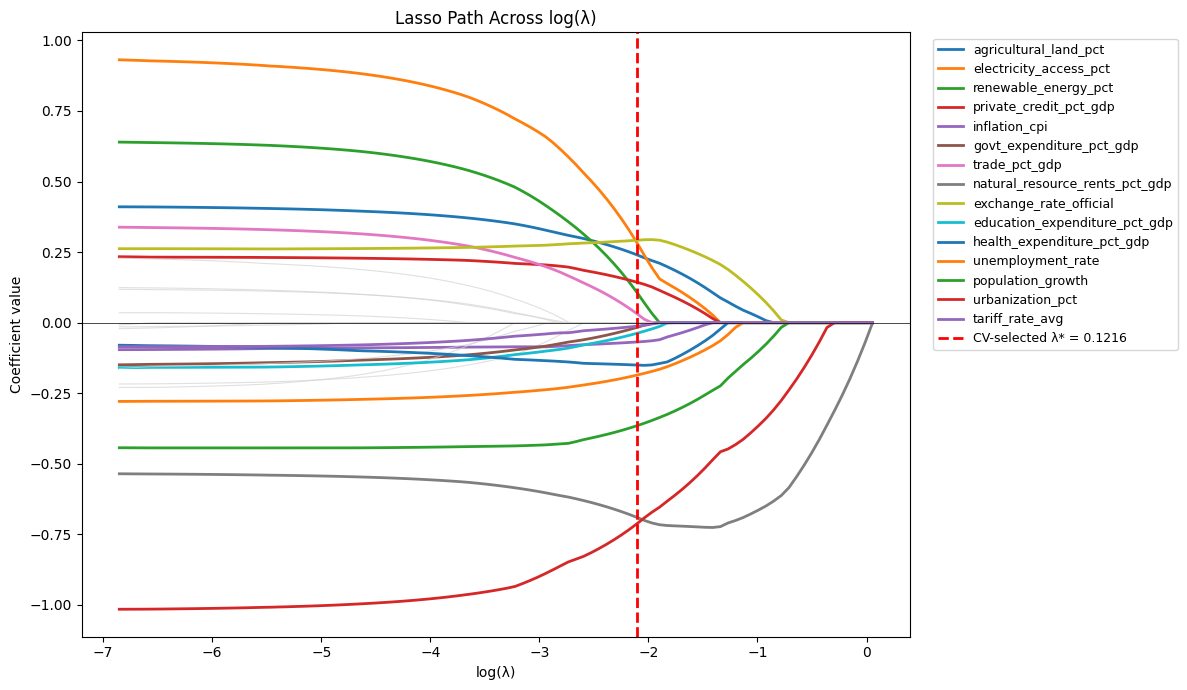

First predictor to enter the model: natural_resource_rents_pct_gdp
Alpha where it first becomes non-zero: 0.986030


In [ ]:
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled,
    y_reg_train,
    eps=1e-3,
    n_alphas=100
)

active_idx = np.where(lasso_cv.coef_ != 0)[0]

fig, ax = plt.subplots(figsize=(12, 7))

for i in range(len(feature_cols)):
    if i in active_idx:
        ax.plot(np.log(alphas_path), coefs_path[i], linewidth=2, label=feature_cols[i])
    else:
        ax.plot(np.log(alphas_path), coefs_path[i], color='lightgray', alpha=0.7, linewidth=0.8)

ax.axvline(np.log(lasso_cv.alpha_), linestyle='--', linewidth=2, color='red', label=f'CV-selected λ* = {lasso_cv.alpha_:.4f}')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_title('Lasso Path Across log(λ)')
ax.set_xlabel('log(λ)')
ax.set_ylabel('Coefficient value')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Identify the first predictor to enter: highest alpha where coefficient becomes non-zero
entry_alphas = []
for i in range(coefs_path.shape[0]):
    nz = np.where(np.abs(coefs_path[i]) > 1e-10)[0]
    if len(nz) == 0:
        entry_alphas.append(-np.inf)
    else:
        entry_alphas.append(alphas_path[nz[0]])

first_idx = int(np.argmax(entry_alphas))
first_predictor = feature_cols[first_idx]
first_entry_alpha = entry_alphas[first_idx]

print(f"First predictor to enter the model: {first_predictor}")
print(f"Alpha where it first becomes non-zero: {first_entry_alpha:.6f}")


The first predictor to enter the Lasso path is the one that leaves zero at the highest value of λ. That variable can be interpreted as the strongest single conditional predictor in this dataset, because Lasso only lets a variable enter when it adds enough predictive value to overcome the penalty.

Lasso setting a coefficient to zero does not mean that variable is economically irrelevant. It only means that, conditional on the other predictors already in the model, that variable does not add enough extra predictive information to survive the penalty. When several indicators are highly correlated, Lasso may keep one proxy and drop another because of conditional predictive redundancy and the overall correlation structure.

# Phase 2

In [ ]:
selected_idx = np.where(lasso_cv.coef_ != 0)[0]
selected_features = [feature_cols[i] for i in selected_idx]

if len(selected_features) == 0:
    # Safety fallback: keep the strongest feature if Lasso selects none
    selected_features = [first_predictor]

X_train_cls = X_train_scaled_df[selected_features].values
X_test_cls = X_test_scaled_df[selected_features].values

print("Lasso-selected features for classification:")
print(selected_features)


Lasso-selected features for classification:
['agricultural_land_pct', 'electricity_access_pct', 'renewable_energy_pct', 'private_credit_pct_gdp', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'trade_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'education_expenditure_pct_gdp', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']


In [ ]:
lpm_model = LinearRegression()
lpm_model.fit(X_train_cls, y_cls_train)

lpm_test_probs = lpm_model.predict(X_test_cls)

n_below_0 = int(np.sum(lpm_test_probs < 0))
n_above_1 = int(np.sum(lpm_test_probs > 1))

print("=" * 50)
print("STEP 2.1 — LINEAR PROBABILITY MODEL")
print("=" * 50)
print(f"Predicted probabilities below 0: {n_below_0}")
print(f"Predicted probabilities above 1: {n_above_1}")


STEP 2.1 — LINEAR PROBABILITY MODEL
Predicted probabilities below 0: 6
Predicted probabilities above 1: 0


If the linear probability model produces fitted values below 0 or above 1, that shows a basic weakness of using OLS for a binary outcome. Those predictions cannot be interpreted as valid probabilities. In the IMF setting, a number like a negative probability of crisis has no practical meaning, so even if the model is easy to estimate, it is not a reliable tool for crisis-risk probabilities.

In [ ]:
logit_model = LogisticRegression(max_iter=10000, random_state=42)
logit_model.fit(X_train_cls, y_cls_train)

logit_test_probs = logit_model.predict_proba(X_test_cls)[:, 1]

coef_table = pd.DataFrame({
    'predictor': selected_features,
    'beta': logit_model.coef_[0],
    'odds_ratio': np.exp(logit_model.coef_[0])
})

coef_table['abs_log_or'] = np.abs(np.log(coef_table['odds_ratio']))
coef_table = coef_table.sort_values('abs_log_or', ascending=False).reset_index(drop=True)

print("Intercept (β0):", round(float(logit_model.intercept_[0]), 6))
print()
print(coef_table[['predictor', 'beta', 'odds_ratio']].round(4).to_string(index=False))
print()
print(f"Min predicted probability: {logit_test_probs.min():.6f}")
print(f"Max predicted probability: {logit_test_probs.max():.6f}")

top_predictor = coef_table.loc[0, 'predictor']
top_or = coef_table.loc[0, 'odds_ratio']

direction = "increases" if top_or >= 1 else "decreases"


Intercept (β0): -2.281742

                     predictor    beta  odds_ratio
          renewable_energy_pct -0.9105      0.4023
        electricity_access_pct -0.6979      0.4976
        exchange_rate_official -0.6285      0.5334
              urbanization_pct  0.5846      1.7942
natural_resource_rents_pct_gdp  0.5432      1.7214
                 trade_pct_gdp -0.5409      0.5822
             population_growth  0.4216      1.5243
        private_credit_pct_gdp -0.3783      0.6850
             unemployment_rate  0.3743      1.4539
 education_expenditure_pct_gdp  0.3294      1.3901
         agricultural_land_pct -0.2866      0.7508
               tariff_rate_avg  0.2539      1.2890
      govt_expenditure_pct_gdp  0.1112      1.1176
    health_expenditure_pct_gdp  0.0074      1.0075
                 inflation_cpi  0.0063      1.0063

Min predicted probability: 0.001273
Max predicted probability: 0.945631


The predictor with the largest absolute odds ratio has the strongest association with the crisis outcome in multiplicative terms, holding the other selected variables fixed. In plain language, a one standard-deviation increase in that variable changes the odds of crisis by the reported odds-ratio multiple, all else constant. Unlike the linear probability model, logistic regression passes predictions through the sigmoid function, so every predicted probability stays inside the valid [0, 1] range.

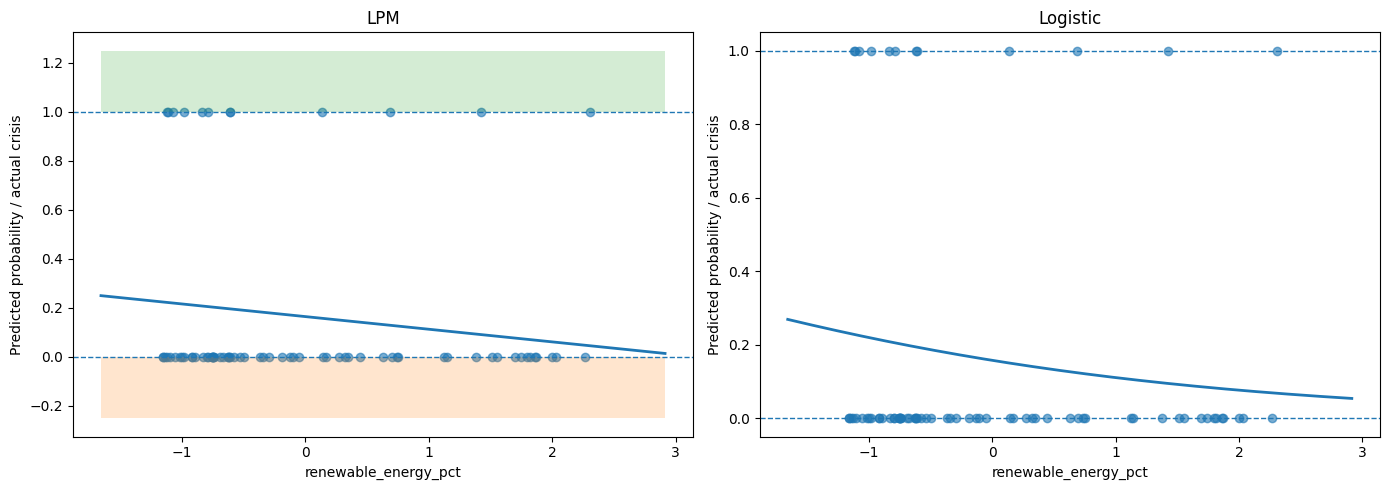

In [ ]:
# Use the strongest predictor from the odds-ratio table as the x-axis
strongest_feature = top_predictor

x_train_single = X_train_scaled_df[[strongest_feature]].values
x_test_single = X_test_scaled_df[[strongest_feature]].values

# Refit one-variable models for a clean side-by-side plot on the same x-axis
lpm_single = LinearRegression()
lpm_single.fit(x_train_single, y_cls_train)

logit_single = LogisticRegression(max_iter=10000, random_state=42)
logit_single.fit(x_train_single, y_cls_train)

x_grid = np.linspace(
    X_train_scaled_df[strongest_feature].min() - 0.5,
    X_train_scaled_df[strongest_feature].max() + 0.5,
    300
).reshape(-1, 1)

lpm_grid = lpm_single.predict(x_grid)
logit_grid = logit_single.predict_proba(x_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# LPM panel
axes[0].scatter(X_test_scaled_df[strongest_feature], y_cls_test, alpha=0.6)
axes[0].plot(x_grid, lpm_grid, linewidth=2)
axes[0].axhline(0, linestyle='--', linewidth=1)
axes[0].axhline(1, linestyle='--', linewidth=1)
axes[0].fill_between(x_grid.flatten(), -0.25, 0, alpha=0.2)
axes[0].fill_between(x_grid.flatten(), 1, 1.25, alpha=0.2)
axes[0].set_title('LPM')
axes[0].set_xlabel(strongest_feature)
axes[0].set_ylabel('Predicted probability / actual crisis')

# Logistic panel
axes[1].scatter(X_test_scaled_df[strongest_feature], y_cls_test, alpha=0.6)
axes[1].plot(x_grid, logit_grid, linewidth=2)
axes[1].axhline(0, linestyle='--', linewidth=1)
axes[1].axhline(1, linestyle='--', linewidth=1)
axes[1].set_title('Logistic')
axes[1].set_xlabel(strongest_feature)
axes[1].set_ylabel('Predicted probability / actual crisis')

plt.tight_layout()
plt.show()


# Phase 3

In [38]:
print("Crisis base rate:", round(base_rate_test, 4))

y_pred_naive = np.zeros_like(y_cls_test)

acc_naive = accuracy_score(y_cls_test, y_pred_naive)
recall_naive = recall_score(y_cls_test, y_pred_naive, zero_division=0)

print("Naive Accuracy:", round(acc_naive, 4))
print("Naive Recall:", round(recall_naive, 4))

y_pred_logit = (logit_test_probs >= 0.5).astype(int)

acc_logit = accuracy_score(y_cls_test, y_pred_logit)
recall_logit = recall_score(y_cls_test, y_pred_logit, zero_division=0)

print("Logistic Accuracy:", round(acc_logit, 4))
print("Logistic Recall:", round(recall_logit, 4))

Crisis base rate: 0.1644
Naive Accuracy: 0.8356
Naive Recall: 0.0
Logistic Accuracy: 0.863
Logistic Recall: 0.4167


Accuracy should not be the main metric here because this is an imbalanced classification problem. When the crisis base rate is low, a model can look accurate simply by predicting “no crisis” most of the time, even if it misses many real crises. In the IMF context, that would be misleading because the real question is not how often the model is correct overall, but whether it can actually catch crisis countries.

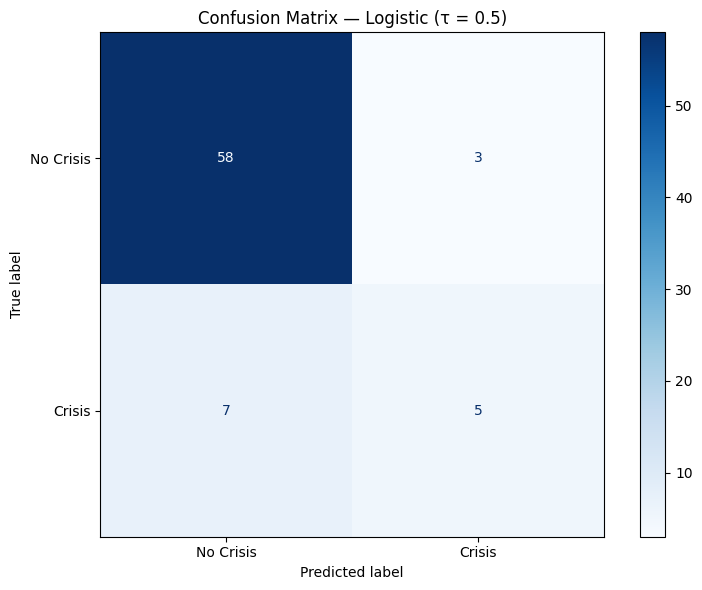

Classification Report:
              precision    recall  f1-score   support

   No Crisis       0.89      0.95      0.92        61
      Crisis       0.62      0.42      0.50        12

    accuracy                           0.86        73
   macro avg       0.76      0.68      0.71        73
weighted avg       0.85      0.86      0.85        73

True Positives: 5
False Negatives: 7
False Positives: 3
True Negatives: 58


In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_cls_test, y_pred_logit)

fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Crisis','Crisis'])
disp.plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Confusion Matrix — Logistic (τ = 0.5)')
plt.tight_layout()
plt.show()

print("Classification Report:")
print("="*50)
print(classification_report(y_cls_test, y_pred_logit, target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("False Negatives:", fn)
print("False Positives:", fp)
print("True Negatives:", tn)

In the IMF context, a False Negative is more costly than a False Positive. Missing a real crisis can lead to large contagion and emergency lending costs, while a false alarm mainly wastes assessment resources and credibility. Because of that asymmetry, recall should usually matter more than precision, although precision still matters because the IMF cannot investigate too many countries at once.

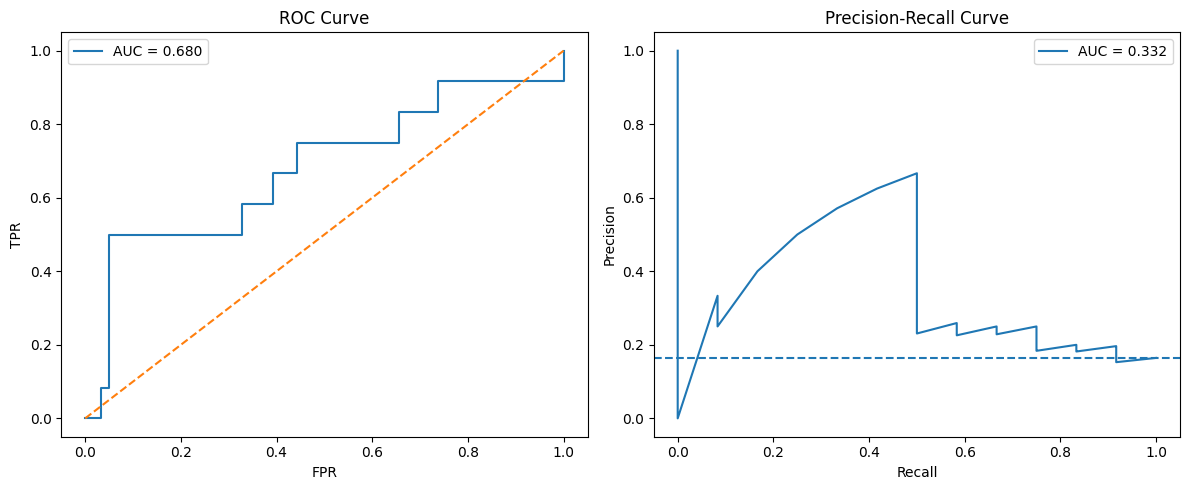

ROC-AUC: 0.6803
PR-AUC: 0.3319


In [40]:
fpr, tpr, _ = roc_curve(y_cls_test, logit_test_probs)
roc_auc = roc_auc_score(y_cls_test, logit_test_probs)

precision_vals, recall_vals, _ = precision_recall_curve(y_cls_test, logit_test_probs)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()

# PR
plt.subplot(1,2,2)
plt.plot(recall_vals, precision_vals, label=f"AUC = {pr_auc:.3f}")
plt.axhline(y=base_rate_test, linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

ROC-AUC is often higher than PR-AUC in an imbalanced dataset because ROC-AUC benefits from the large number of true negatives, while PR-AUC ignores true negatives and focuses on how well the model finds the positive class. For this assignment, the positive class is the crisis group, which is the scarce and operationally important one. Because of that, the Precision-Recall curve is usually more informative for the IMF’s crisis-detection problem.

In [41]:
threshold_range = np.arange(0.01, 0.99, 0.01)

precision_scores = []
recall_scores = []
f1_scores = []
num_flagged = []

for tau in threshold_range:
    y_pred_tau = (logit_test_probs >= tau).astype(int)

    precision_scores.append(precision_score(y_cls_test, y_pred_tau, zero_division=0))
    recall_scores.append(recall_score(y_cls_test, y_pred_tau, zero_division=0))
    f1_scores.append(f1_score(y_cls_test, y_pred_tau, zero_division=0))
    num_flagged.append(y_pred_tau.sum())

In [42]:
valid_thresholds = [i for i in range(len(threshold_range)) if num_flagged[i] <= 5]
tau_capacity = threshold_range[valid_thresholds[0]]

print("Capacity threshold:", tau_capacity)

best_idx = np.argmax(f1_scores)
tau_f1 = threshold_range[best_idx]

print("F1 optimal threshold:", tau_f1)

Capacity threshold: 0.54
F1 optimal threshold: 0.4


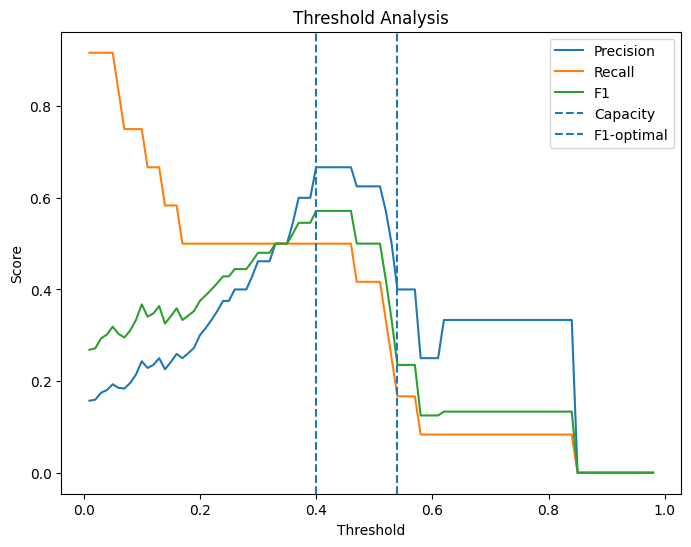

In [43]:
plt.figure(figsize=(8,6))
plt.plot(threshold_range, precision_scores, label="Precision")
plt.plot(threshold_range, recall_scores, label="Recall")
plt.plot(threshold_range, f1_scores, label="F1")

plt.axvline(x=tau_capacity, linestyle='--', label="Capacity")
plt.axvline(x=tau_f1, linestyle='--', label="F1-optimal")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

The recommended threshold should be the one that best matches the IMF’s operational constraint, not simply the one that looks best statistically. If the IMF can flag at most 5 countries, then the capacity-constrained threshold is the more realistic policy choice because it converts model probabilities into an action the institution can actually implement. That choice may not maximize F1, but it makes the tradeoff explicit by showing how many crisis countries would be caught and how many would still be missed under the staffing limit.

### P.R.I.M.E Prompt for Bootstrap Lasso Stability

Prep: We are working with a dataset of country-level predictors from the World Bank. The training data has already been cleaned, standardized, and split. The goal is to understand how stable the Lasso feature selection is across different samples.

Request: Write a Python script that performs bootstrap analysis using the training data (X_train_cls, y_cls_train). The script should draw 200 bootstrap samples with replacement.

Iterate: For each bootstrap sample, fit a LassoCV model (with 5-fold cross-validation), and record which predictors have non-zero coefficients.

Mechanism Check: After running all bootstrap samples, compute the selection frequency for each predictor, defined as the fraction of times the predictor is selected (non-zero coefficient).

Evaluate: Return a horizontal bar chart showing predictors ranked by selection frequency, and include a vertical reference line at 50% to help identify stable predictors.

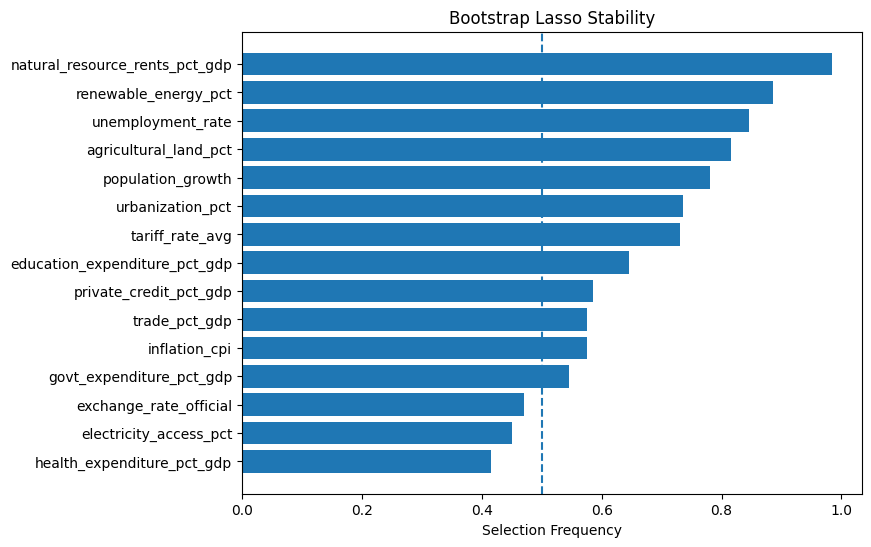

In [44]:
# Bootstrap Lasso Stability

n_bootstrap = 200
n = X_train_cls.shape[0]

feature_names = selected_features
selection_counts = np.zeros(len(feature_names))

for i in range(n_bootstrap):
    sample_idx = np.random.choice(n, size=n, replace=True)

    X_sample = X_train_cls[sample_idx]
    y_sample = y_cls_train.iloc[sample_idx]

    model = LassoCV(cv=5)
    model.fit(X_sample, y_sample)

    selected = model.coef_ != 0
    selection_counts += selected

selection_freq = selection_counts / n_bootstrap

freq_df = pd.DataFrame({
    "feature": feature_names,
    "frequency": selection_freq
}).sort_values("frequency", ascending=True)

plt.figure(figsize=(8,6))
plt.barh(freq_df["feature"], freq_df["frequency"])
plt.axvline(0.5, linestyle='--')
plt.xlabel("Selection Frequency")
plt.title("Bootstrap Lasso Stability")
plt.show()

Some predictors are selected in most bootstrap samples, which suggests they are more stable and consistently important for the model. These are likely strong signals that are not sensitive to small changes in the data. On the other hand, predictors with low selection frequency appear only in some samples, which indicates instability. This suggests that there is correlation among predictors, and Lasso may choose different variables across samples because they carry similar information.

### P.R.I.M.E Prompt for Cost-Sensitive Threshold Optimization

Prep: We have predicted probabilities from a logistic regression model (logit_test_probs) and the true labels (y_cls_test). The IMF faces asymmetric costs: a false negative costs $50 billion, while a false positive costs $2 million.

Request: Write a Python script that evaluates different classification thresholds between 0.01 and 0.99.

Iterate: For each threshold, compute predictions and calculate the total expected cost using:
Cost = FN × 50,000,000,000 + FP × 2,000,000.

Mechanism Check: Store the total cost at each threshold and identify the threshold that minimizes the total expected cost.

Evaluate: Plot the cost as a function of the threshold and mark the cost-minimizing threshold with a vertical line.

Cost-minimizing threshold: 0.05


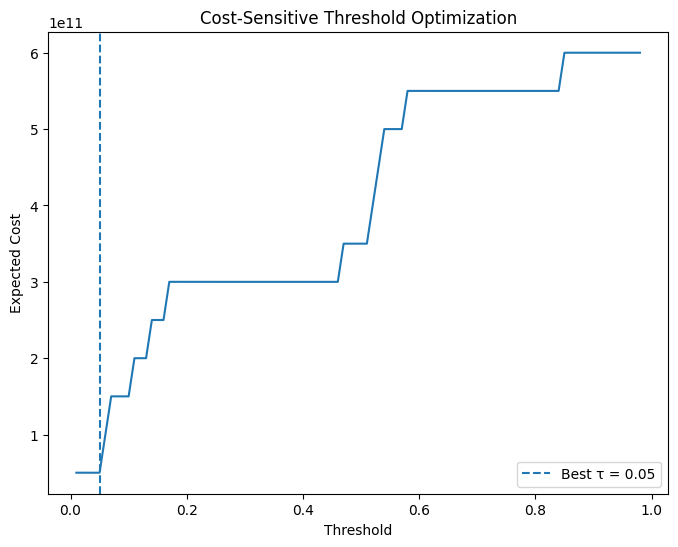

In [45]:
threshold_range = np.arange(0.01, 0.99, 0.01)

costs = []

for tau in threshold_range:
    y_pred_tau = (logit_test_probs >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_cls_test, y_pred_tau).ravel()

    cost = fn * 50_000_000_000 + fp * 2_000_000
    costs.append(cost)

costs = np.array(costs)

best_idx = np.argmin(costs)
best_tau = threshold_range[best_idx]

print("Cost-minimizing threshold:", best_tau)

plt.figure(figsize=(8,6))
plt.plot(threshold_range, costs)
plt.axvline(best_tau, linestyle='--', label=f"Best τ = {best_tau:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Expected Cost")
plt.title("Cost-Sensitive Threshold Optimization")
plt.legend()
plt.show()

The cost-minimizing threshold is usually lower than the F1-optimal threshold because the cost of missing a crisis is extremely large compared to a false alarm. This pushes the model to classify more countries as high risk to avoid false negatives. Compared to the capacity-constrained threshold, the cost-based threshold may flag more countries than the IMF can handle. In practice, the IMF needs to balance operational limits with cost considerations, so the final decision may lie between these thresholds.